# Explainable Plant Disease Detection System Using CNN and Transfer Learning

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

## 1. Import Libraries

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

E0000 00:00:1780741683.721209      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780741683.782621      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780741684.345933      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780741684.345978      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780741684.345981      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780741684.345983      16 computation_placer.cc:177] computation placer already registered. Please check linka

## 2. Load Dataset

In [3]:
dataset_path = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"

classes = sorted(os.listdir(dataset_path))

print("Number of classes:", len(classes))
print("\nClass Names:")

for i, cls in enumerate(classes, start=1):
    print(f"{i}. {cls}")

Number of classes: 15

Class Names:
1. Pepper__bell___Bacterial_spot
2. Pepper__bell___healthy
3. Potato___Early_blight
4. Potato___Late_blight
5. Potato___healthy
6. Tomato_Bacterial_spot
7. Tomato_Early_blight
8. Tomato_Late_blight
9. Tomato_Leaf_Mold
10. Tomato_Septoria_leaf_spot
11. Tomato_Spider_mites_Two_spotted_spider_mite
12. Tomato__Target_Spot
13. Tomato__Tomato_YellowLeaf__Curl_Virus
14. Tomato__Tomato_mosaic_virus
15. Tomato_healthy


## 3. Dataset Exploration

In [4]:
classes = sorted(os.listdir(dataset_path))

print("Number of Classes:", len(classes))
print("\nClass Names:\n")

for i, cls in enumerate(classes, start=1):
    print(f"{i}. {cls}")

Number of Classes: 15

Class Names:

1. Pepper__bell___Bacterial_spot
2. Pepper__bell___healthy
3. Potato___Early_blight
4. Potato___Late_blight
5. Potato___healthy
6. Tomato_Bacterial_spot
7. Tomato_Early_blight
8. Tomato_Late_blight
9. Tomato_Leaf_Mold
10. Tomato_Septoria_leaf_spot
11. Tomato_Spider_mites_Two_spotted_spider_mite
12. Tomato__Target_Spot
13. Tomato__Tomato_YellowLeaf__Curl_Virus
14. Tomato__Tomato_mosaic_virus
15. Tomato_healthy


In [5]:
class_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    class_counts[cls] = len(os.listdir(class_path))

print("\nClass Distribution:\n")

for cls in sorted(class_counts.keys()):
    print(f"{cls:<45} : {class_counts[cls]}")

print("\nTotal Images:", sum(class_counts.values()))


Class Distribution:

Pepper__bell___Bacterial_spot                 : 997
Pepper__bell___healthy                        : 1478
Potato___Early_blight                         : 1000
Potato___Late_blight                          : 1000
Potato___healthy                              : 152
Tomato_Bacterial_spot                         : 2127
Tomato_Early_blight                           : 1000
Tomato_Late_blight                            : 1909
Tomato_Leaf_Mold                              : 952
Tomato_Septoria_leaf_spot                     : 1771
Tomato_Spider_mites_Two_spotted_spider_mite   : 1676
Tomato__Target_Spot                           : 1404
Tomato__Tomato_YellowLeaf__Curl_Virus         : 3209
Tomato__Tomato_mosaic_virus                   : 373
Tomato_healthy                                : 1591

Total Images: 20639


## 4. Image Preprocessing

In [6]:
img_size = 64
batch_size = 64

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


## 5. Data Augmentation


In [7]:
train_aug = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

train_data = train_aug.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 16516 images belonging to 15 classes.


## 6. Custom CNN Model

In [8]:
num_classes = len(classes)

print("Number of Classes:", num_classes)

Number of Classes: 15


In [9]:
cnn_model = models.Sequential([
    layers.Input(shape=(img_size, img_size, 3)),

    layers.Conv2D(16, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,719 (112.18 KB)

 Trainable params: 28,719 (112.18 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history_cnn = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 179s 683ms/step - accuracy: 0.2315 - loss: 2.3382 - val_accuracy: 0.3091 - val_loss: 2.0210
Epoch 2/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 61s 234ms/step - accuracy: 0.3878 - loss: 1.8732 - val_accuracy: 0.4146 - val_loss: 1.7761
Epoch 3/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 60s 230ms/step - accuracy: 0.4876 - loss: 1.5671 - val_accuracy: 0.5471 - val_loss: 1.3964
Epoch 4/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 61s 236ms/step - accuracy: 0.5507 - loss: 1.3806 - val_accuracy: 0.5206 - val_loss: 1.4379
Epoch 5/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 63s 244ms/step - accuracy: 0.5824 - loss: 1.2660 - val_accuracy: 0.4857 - val_loss: 1.6652


## 7. Transfer Learning Model

In [11]:
base_model = MobileNetV2(
    weights=None,
    include_top=False,
    input_shape=(img_size, img_size, 3)
)

base_model.trainable = True

mobilenet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_64             │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,887 (9.25 MB)

 Trainable params: 2,389,775 (9.12 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [13]:
history_mobile = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 167s 534ms/step - accuracy: 0.2873 - loss: 2.2512 - val_accuracy: 0.0859 - val_loss: 2.6584
Epoch 2/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 136s 523ms/step - accuracy: 0.4442 - loss: 1.7923 - val_accuracy: 0.0813 - val_loss: 2.7195
Epoch 3/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 133s 514ms/step - accuracy: 0.5184 - loss: 1.5455 - val_accuracy: 0.0813 - val_loss: 2.7960
Epoch 4/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 137s 529ms/step - accuracy: 0.5589 - loss: 1.3990 - val_accuracy: 0.0924 - val_loss: 2.9487
Epoch 5/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 134s 518ms/step - accuracy: 0.6310 - loss: 1.2242 - val_accuracy: 0.0924 - val_loss: 2.9946


## 8. Model Evaluation

In [14]:
y_true = val_data.classes

y_pred_probs = cnn_model.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(val_data.class_indices.keys())

# Check what classes the model is predicting
unique, counts = np.unique(y_pred, return_counts=True)

print("Predicted Class Distribution:")
for u, c in zip(unique, counts):
    print(class_names[u], ":", c)

# Classification Report
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step
Predicted Class Distribution:
Pepper__bell___Bacterial_spot : 150
Pepper__bell___healthy : 456
Potato___Early_blight : 224
Potato___Late_blight : 12
Tomato_Bacterial_spot : 210
Tomato_Early_blight : 106
Tomato_Late_blight : 147
Tomato_Leaf_Mold : 129
Tomato_Septoria_leaf_spot : 289
Tomato_Spider_mites_Two_spotted_spider_mite : 417
Tomato__Target_Spot : 783
Tomato__Tomato_YellowLeaf__Curl_Virus : 498
Tomato__Tomato_mosaic_virus : 63
Tomato_healthy : 638
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.41      0.31      0.35       199
                     Pepper__bell___healthy       0.46      0.71      0.56       295
                      Potato___Early_blight       0.61      0.68      0.64       200
                       Potato___Late_blight       0.08      0.01      0.01       200
                           Potato___healthy       0.00      0.00      0.00  

## 9. Confusion Matrix

65/65 ━━━━━━━━━━━━━━━━━━━━ 10s 135ms/step


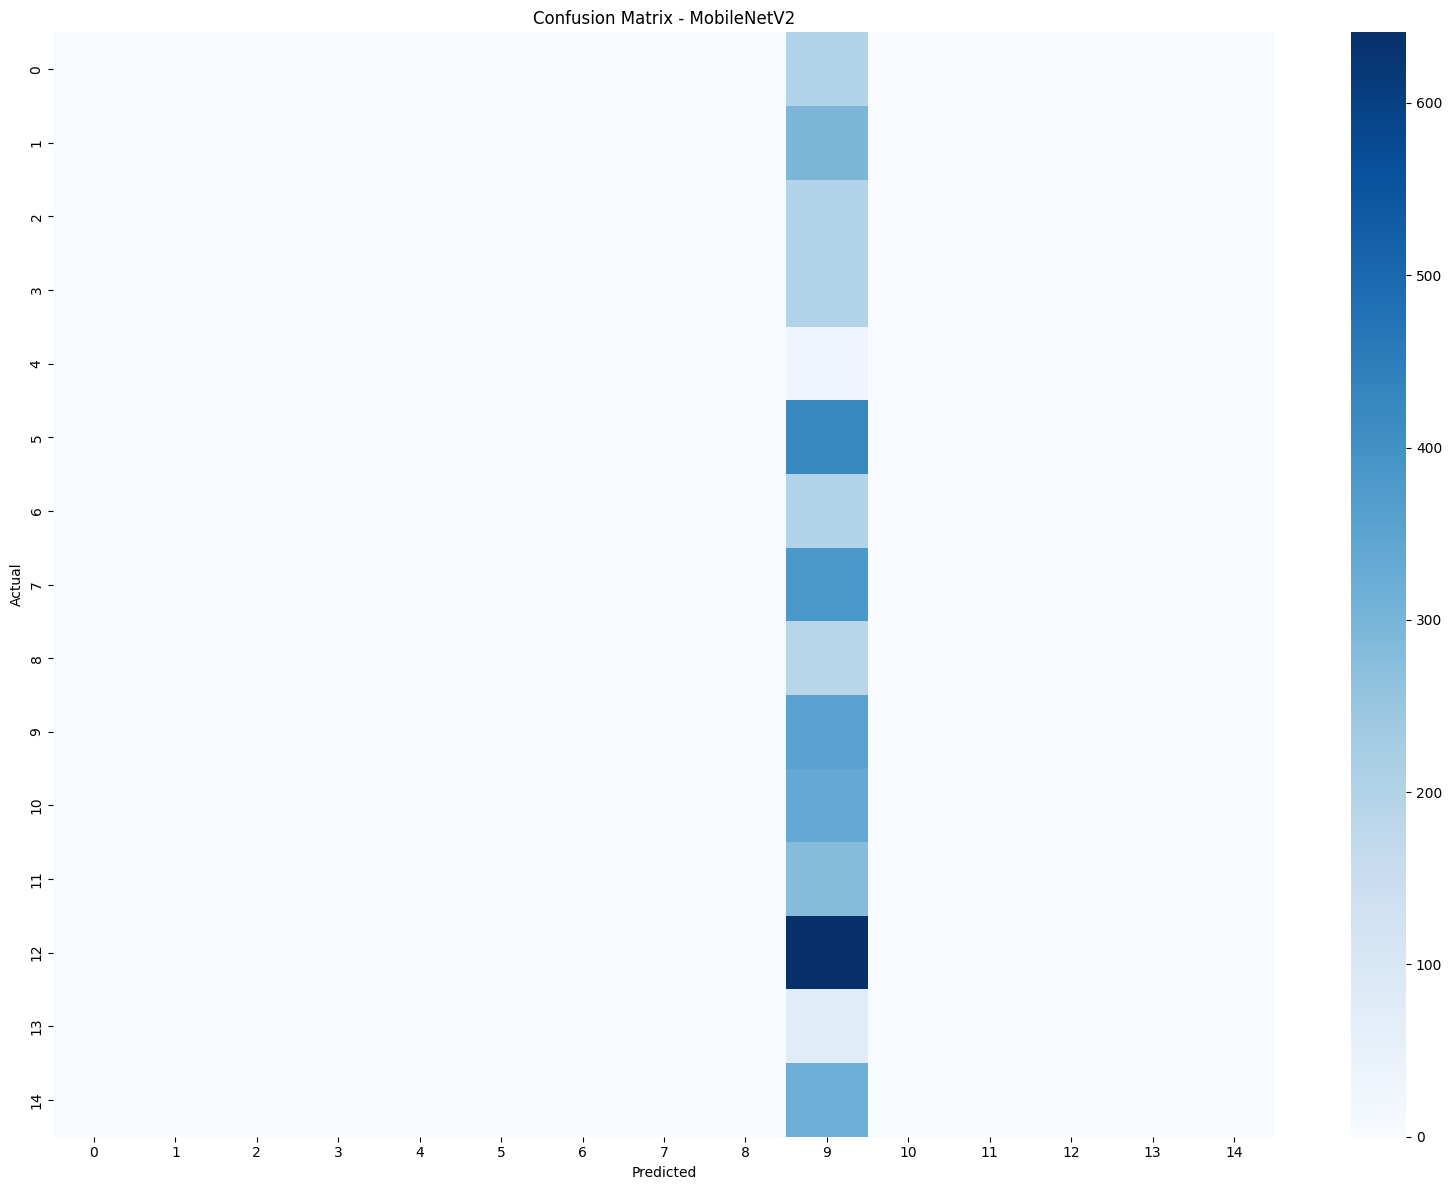

In [15]:
y_true = val_data.classes
y_pred_probs = mobilenet_model.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(val_data.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16,12))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix - MobileNetV2")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

## 10. Accuracy and Loss Curves

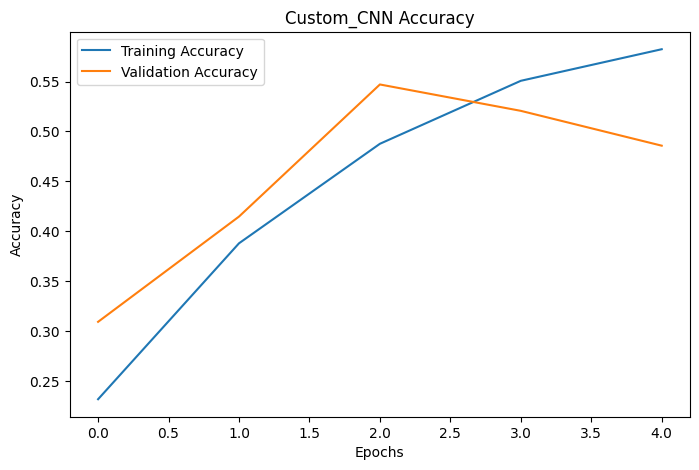

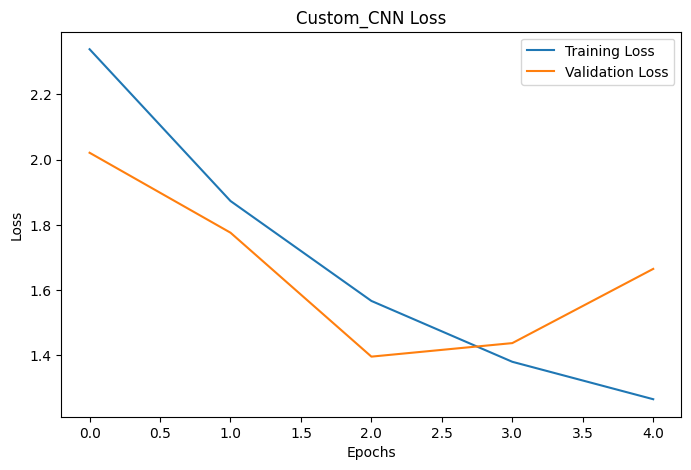

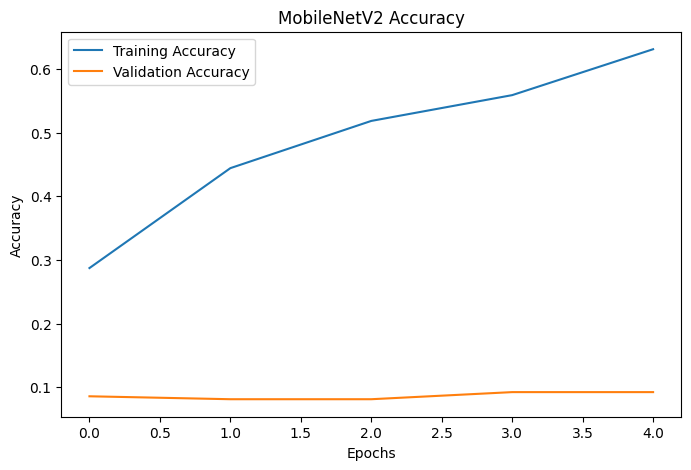

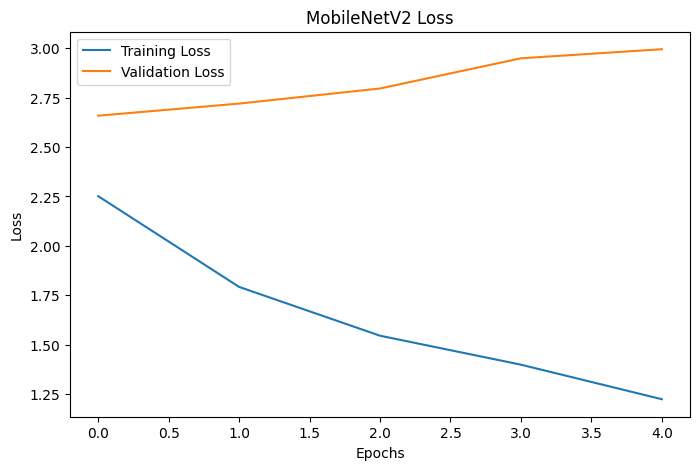

In [16]:
def plot_training(history, model_name):
    plt.figure(figsize=(8,5))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(model_name + " Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.savefig(model_name + "_accuracy.png")
    plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(model_name + " Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.savefig(model_name + "_loss.png")
    plt.show()

plot_training(history_cnn, "Custom_CNN")
plot_training(history_mobile, "MobileNetV2")

## 11. Future Enhancement: Grad-CAM Explainability

In [17]:
cnn_acc = max(history_cnn.history['val_accuracy'])
cnn_loss = min(history_cnn.history['val_loss'])

mobile_acc = max(history_mobile.history['val_accuracy'])
mobile_loss = min(history_mobile.history['val_loss'])

## 12. Model Comparison

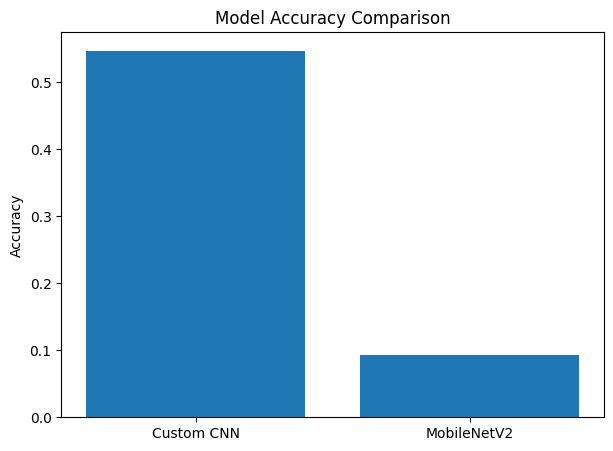

Custom CNN Accuracy: 0.5470645427703857 Loss: 1.3964390754699707
MobileNetV2 Accuracy: 0.09243085980415344 Loss: 2.658409595489502


In [18]:
models_list = ["Custom CNN", "MobileNetV2"]
accuracy_list = [cnn_acc, mobile_acc]
loss_list = [cnn_loss, mobile_loss]

plt.figure(figsize=(7,5))
plt.bar(models_list, accuracy_list)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.savefig("model_comparison.png")
plt.show()

for model, acc, loss in zip(models_list, accuracy_list, loss_list):
    print(model, "Accuracy:", acc, "Loss:", loss)

## 13. Save Models

In [19]:
cnn_model.save("custom_cnn_model.keras")
mobilenet_model.save("mobilenetv2_model.keras")

## 14. Conclusion

In this project, a CNN-based plant disease detection system was developed using the PlantVillage dataset. A custom CNN model and a MobileNetV2-based architecture were implemented and evaluated using standard classification metrics. The generated confusion matrix, classification report, and performance curves provide insights into model behavior. Future work includes implementing Grad-CAM explainability and further hyperparameter tuning to improve classification performance.